<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/graviationalwave_GW170814.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Graviational Wave GW170814**

Gravitational wave event GW170814 as detected by LIGO detectors at Hanford and Livingston, and the Virgo detector

https://de.m.wikipedia.org/wiki/GW170814

In [ ]:
!pip install gwpy matplotlib -q

In [2]:
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

# Define the event time for GW170814
event_time = 1186741861.5  # GPS time of GW170814

# Load strain data for Hanford, Livingston, and Virgo detectors
hanford_data = TimeSeries.fetch_open_data('H1', event_time - 16, event_time + 16, cache=True)
livingston_data = TimeSeries.fetch_open_data('L1', event_time - 16, event_time + 16, cache=True)
virgo_data = TimeSeries.fetch_open_data('V1', event_time - 16, event_time + 16, cache=True)

# Apply a bandpass filter between 30 and 400 Hz to remove noise outside this range
hanford_data_bp = hanford_data.bandpass(30, 400)
livingston_data_bp = livingston_data.bandpass(30, 400)
virgo_data_bp = virgo_data.bandpass(30, 400)

# Whiten the data to make the noise spectrum flat across frequencies
hanford_data_white = hanford_data_bp.whiten()
livingston_data_white = livingston_data_bp.whiten()
virgo_data_white = virgo_data_bp.whiten()

# Generate a Q-transform plot of the whitened data around the event time
q_transform_h1 = hanford_data_white.q_transform(outseg=(event_time-0.2, event_time + 0.2))
q_transform_l1 = livingston_data_white.q_transform(outseg=(event_time-0.2, event_time + 0.2))
q_transform_v1 = virgo_data_white.q_transform(outseg=(event_time-0.2, event_time + 0.2))

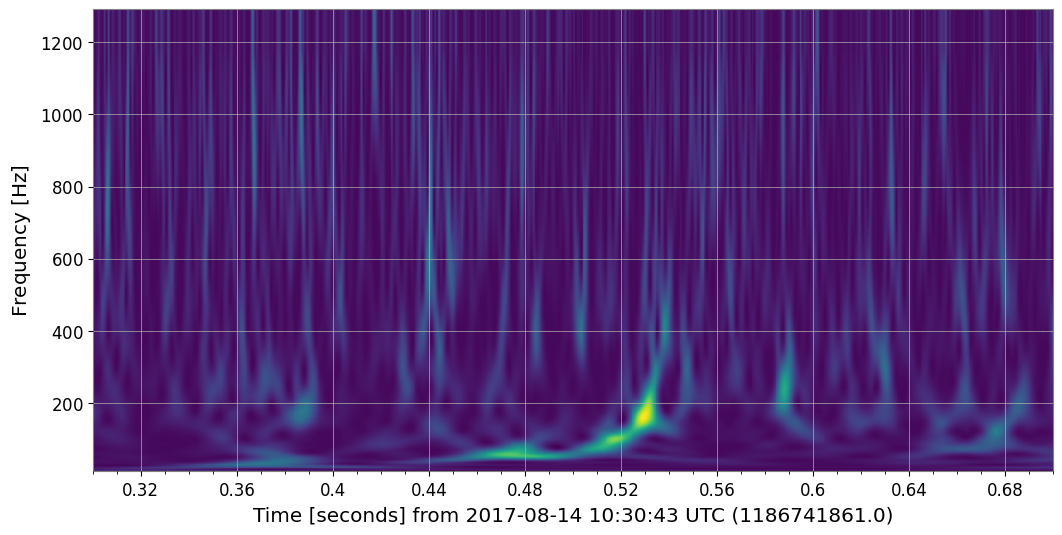

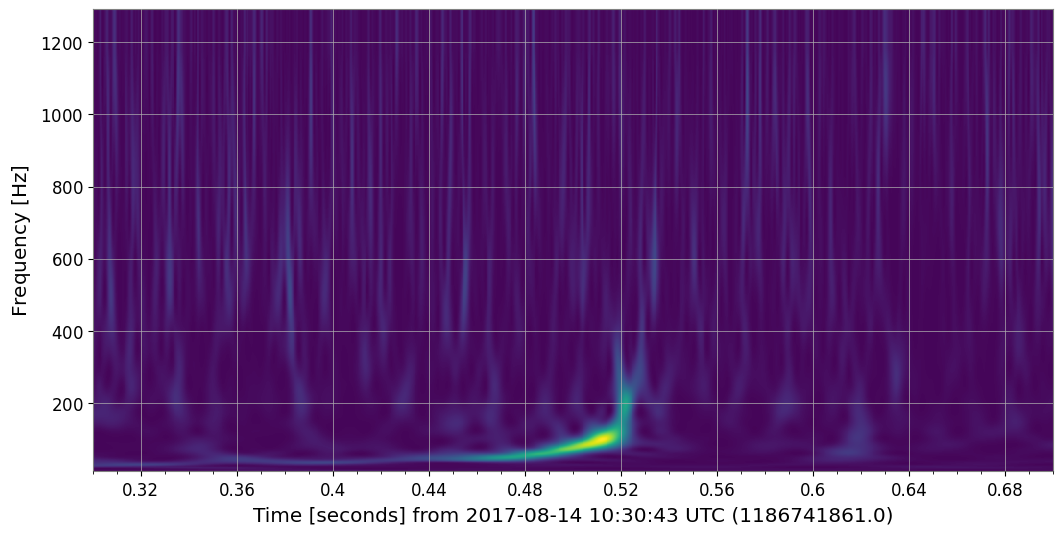

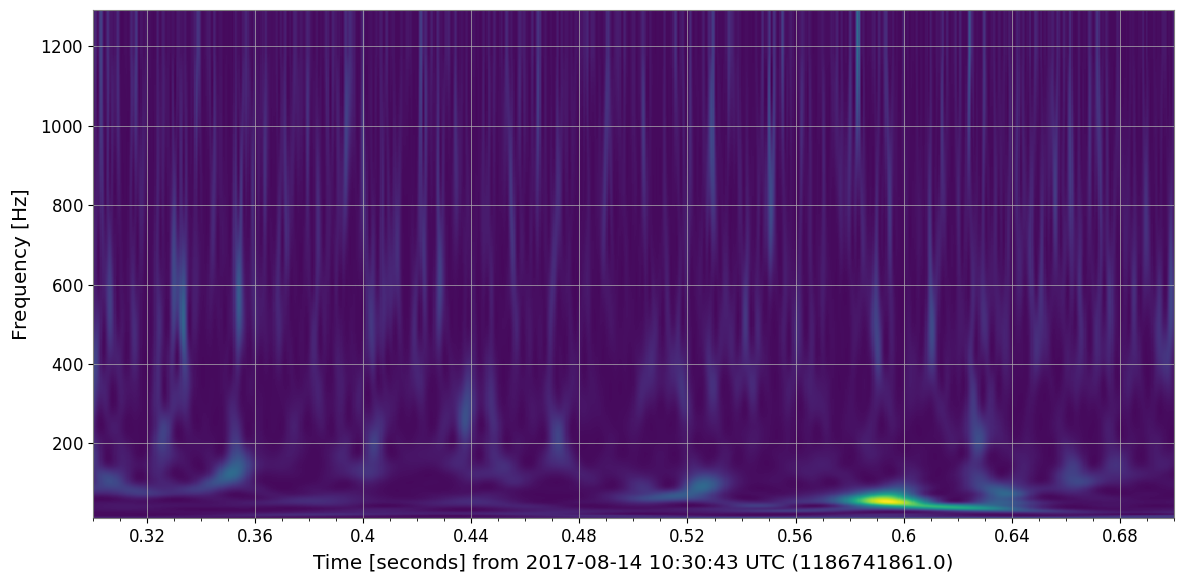

In [3]:
# Create the plots
#fig, axs = plt.subplots(3, 2, figsize=(10, 15))

# Plot the Q-transform for Hanford
plot_h1 = q_transform_h1.plot()
#plot_h1.colorbar(label="Normalized Energy")
#axs[0].set_title("Hanford Q-Transform")

# Plot the Q-transform for Livingston
plot_l1 = q_transform_l1.plot()
#plot_l1.colorbar(label="Normalized Energy")
#axs[1].set_title("Livingston Q-Transform")

# Plot the Q-transform for Virgo
plot_v1 = q_transform_v1.plot()
#plot_v1.colorbar(label="Normalized Energy")
#axs[2].set_title("Virgo Q-Transform")

plt.tight_layout()
plt.show()